## Sequential data
 - Ordered in time or space
 - Order of the data points contains dependencies between them
  - Examples of sequential data:
    - Time series
    - Text (when you try to predict the meaning, or the sequential words)
    - Audio waves

## Electricity consumption prediction
- Task: Predict future electricity consumption based on past data patterns
- Electricity consumption dataset: https://archive.ics.uci.edu/dataset/321/electricityloaddiagrams20112014

### Train-test split
- **No random splitting for time series!**
- **Look-agead bias:** model has info about the future
- Solution: split by time
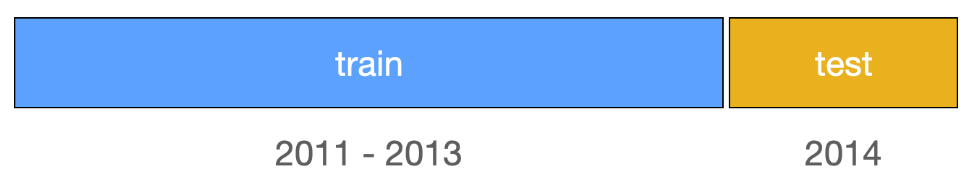

### Creating sequences
- Sequence length = number of data points in one training example
    - 24 * 4 = 96 -> consider last 24 hours of data
- Pedict single next data point
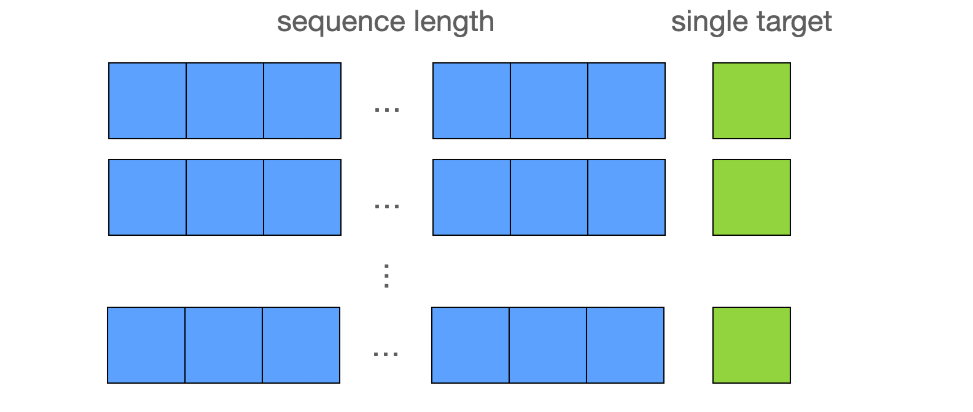

- Take data and sequence length as inputs
- Initialize inputs and targets lists
- Iterate over data point
- Define inputs and target
- Append to pre-in

In [ ]:
import numpy as np
import pandas as pd

def create_sequences(df, seq_length):
    xs, ys = [], []
    for i in range(len(df) - seq_length):
        x = df.iloc[i:(i + seq_length), 1]
        y = df.iloc[i + seq_length, 1]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

In [ ]:
with open('8.LD2011_2014.txt', 'r') as f:
    content = f.read()
    df = pd.read_csv(content, sep='\t', header=None)

In [ ]:
X_train, y_train = create_sequences(train_data, seq_length)
print(X_train.shape, y_train.shape)

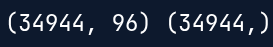

Convert them to a Torch Dataset

In [ ]:
import torch
from torch.utils.data import TensorDataset

dataset_train = TensorDataset(
    torch.from_numpy(X_train).float(),
    torch.from_numpy(y_train).float()
)

## Applicability to other sequential data
Same techniques are applicable to other sequences:
- Large Language Models
- Speech recognition